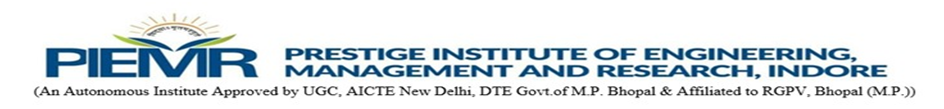

<h2 align="left">Department of AI & Data Science</h2>

<h2 align="left">Data Mining & Warehousing Lab </h2>

<h2 align="left"> Course Instructor: Dr. Rajesh Kumar</h2>

<h2 align="left">Experiment 5: MARKET BASKET ANALYSIS USING APRIORIALGORITHM</h2>

Course: Data Mining & Warehousing

IMPORT LIBRARIES

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules



### LOAD AND PREPARE DATA

In this experiment, we will perform
Market Basket Analysis (MBA)
using the
Online Retail Dataset.

Market Basket Analysis helps us discover:

Frequently purchased products

Product associations

Customer buying behavior

Recommendation patterns

The dataset contains:
Invoice Numbers

Product Descriptions

Quantities

Customer IDs

Import Dataset

Read the Excel file from the local system

Update the path according to your computer.

In [2]:
# File path

file_path = r"C:\Users\rjesh\Online Retail.xlsx"

# Read Excel file

df = pd.read_excel(file_path)




Display Dataset

Display the first 5 rows.

Understand the structure of the dataset.

In [3]:
# First 5 rows

print(df.head())



  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


Dataset Shape


Check total rows and columns.

In [4]:
# Number of rows and columns

print(df.shape)




(541909, 8)


Column Names

Display dataset columns.

In [5]:
print(df.columns)



Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


Check Missing Values

Identify null or missing values.

In [6]:
print(df.isnull().sum())



InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


DATA CLEANING

Data cleaning is very important before applying the Apriori Algorithm.


Remove Missing Customer IDs

Remove rows where CustomerID is missing.


In [7]:
df.dropna(subset=['CustomerID'], inplace=True)

J



(406829, 8)


Remove Cancelled Transactions

Invoices starting with
C
indicate cancelled orders.

In [8]:
df = df[~df['InvoiceNo'].astype(str).str.contains('C')]

print(df.shape)




(397924, 8)


Remove Negative Quantities

Keep only positive quantities.

In [9]:
df = df[df['Quantity'] > 0]

print(df.shape)



(397924, 8)


CREATE BASKET MATRIX

A basket matrix represents:

Rows → Transactions

Columns → Products

Values → Quantity Purchased

Create Transaction Matrix

In [10]:
basket = (df[df['Country'] == 'United Kingdom']
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum()
          .unstack()
          .fillna(0))



Display Basket Matrix

In [11]:
print(basket.head())



Description   4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE  \
InvoiceNo                                                                     
536365                                  0.0                             0.0   
536366                                  0.0                             0.0   
536367                                  0.0                             0.0   
536368                                  0.0                             0.0   
536369                                  0.0                             0.0   

Description   DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK  \
InvoiceNo                                                       
536365                      0.0                           0.0   
536366                      0.0                           0.0   
536367                      0.0                           0.0   
536368                      0.0                           0.0   
536369                      0.0                         

BINARY ENCODING

The Apriori Algorithm works on binary data.

1 → Product Purchased

0 → Product Not Purchased


Define Encoding Function

Apply Binary Encoding

In [14]:
def encode_units(x):

    if x <= 0:
        return 0

    if x >= 1:
        return 1

basket_sets = basket.applymap(encode_units)

print(basket_sets.head())



Description   4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE  \
InvoiceNo                                                                     
536365                                    0                               0   
536366                                    0                               0   
536367                                    0                               0   
536368                                    0                               0   
536369                                    0                               0   

Description   DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK  \
InvoiceNo                                                       
536365                        0                             0   
536366                        0                             0   
536367                        0                             0   
536368                        0                             0   
536369                        0                         

APRIORI ALGORITHM

The Apriori Algorithm identifies:

Frequent itemsets

Product combinations

Hidden purchasing patterns

Apply Apriori Algorithm

In [15]:
frequent_itemsets = apriori(
    basket_sets,
    min_support=0.02,
    use_colnames=True
)

print(frequent_itemsets.head())



C:\Users\rjesh\anaconda3\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


    support                           itemsets
0  0.022404         (3 STRIPEY MICE FELTCRAFT)
1  0.037720           (6 RIBBONS RUSTIC CHARM)
2  0.025767  (60 CAKE CASES VINTAGE CHRISTMAS)
3  0.035257      (60 TEATIME FAIRY CAKE CASES)
4  0.026668   (72 SWEETHEART FAIRY CAKE CASES)


In [16]:
def encode_units(x):

    if x <= 0:
        return 0

    if x >= 1:
        return 1

basket_sets = basket.applymap(encode_units)

print(basket_sets.head())



Description   4 PURPLE FLOCK DINNER CANDLES   50'S CHRISTMAS GIFT BAG LARGE  \
InvoiceNo                                                                     
536365                                    0                               0   
536366                                    0                               0   
536367                                    0                               0   
536368                                    0                               0   
536369                                    0                               0   

Description   DOLLY GIRL BEAKER   I LOVE LONDON MINI BACKPACK  \
InvoiceNo                                                       
536365                        0                             0   
536366                        0                             0   
536367                        0                             0   
536368                        0                             0   
536369                        0                         

Display Frequent Itemsets

In [17]:
frequent_itemsets = apriori(
    basket_sets,
    min_support=0.02,
    use_colnames=True
)

print(frequent_itemsets.head(20))



C:\Users\rjesh\anaconda3\lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


     support                           itemsets
0   0.022404         (3 STRIPEY MICE FELTCRAFT)
1   0.037720           (6 RIBBONS RUSTIC CHARM)
2   0.025767  (60 CAKE CASES VINTAGE CHRISTMAS)
3   0.035257      (60 TEATIME FAIRY CAKE CASES)
4   0.026668   (72 SWEETHEART FAIRY CAKE CASES)
5   0.041444       (ALARM CLOCK BAKELIKE GREEN)
6   0.025467       (ALARM CLOCK BAKELIKE IVORY)
7   0.029491        (ALARM CLOCK BAKELIKE PINK)
8   0.045528        (ALARM CLOCK BAKELIKE RED )
9   0.031353     (ANTIQUE SILVER T-LIGHT GLASS)
10  0.021863        (AREA PATROLLED METAL SIGN)
11  0.078083    (ASSORTED COLOUR BIRD ORNAMENT)
12  0.043366    (BAKING SET 9 PIECE RETROSPOT )
13  0.021863       (BAKING SET SPACEBOY DESIGN)
14  0.022284              (BATHROOM METAL SIGN)
15  0.025827           (BLUE HARMONICA IN BOX )
16  0.020302      (CHARLOTTE BAG APPLES DESIGN)
17  0.025167      (CHARLOTTE BAG PINK POLKADOT)
18  0.030512        (CHARLOTTE BAG SUKI DESIGN)
19  0.022103  (CHILDRENS APRON SPACEBOY 

SUPPORT

Support measures how frequently an item or itemset appears in all transactions.

Formula:

Support(A → B) = Transactions containing A and B / Total Transactions

Example:
If Bread appears in 50 out of 1000 transactions:

Support(Bread) = 50 / 1000 = 0.05

Meaning:

Bread appears in 5% of transactions.

ASSOCIATION RULE GENERATION

Association rules discover relationships between products.

Example:

Bread → Butter

Meaning:

Customers buying Bread may also buy Butter

Generate Association Rules

In [18]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

print(rules.head())



                            antecedents                           consequents  \
0          (ALARM CLOCK BAKELIKE GREEN)           (ALARM CLOCK BAKELIKE RED )   
1           (ALARM CLOCK BAKELIKE RED )          (ALARM CLOCK BAKELIKE GREEN)   
2  (GARDENERS KNEELING PAD CUP OF TEA )   (GARDENERS KNEELING PAD KEEP CALM )   
3   (GARDENERS KNEELING PAD KEEP CALM )  (GARDENERS KNEELING PAD CUP OF TEA )   
4      (PINK REGENCY TEACUP AND SAUCER)     (GREEN REGENCY TEACUP AND SAUCER)   

   antecedent support  consequent support   support  confidence       lift  \
0            0.041444            0.045528  0.027269    0.657971  14.451925   
1            0.045528            0.041444  0.027269    0.598945  14.451925   
2            0.037660            0.044567  0.027509    0.730463  16.390122   
3            0.044567            0.037660  0.027509    0.617251  16.390122   
4            0.029611            0.036759  0.024266    0.819473  22.293137   

   representativity  leverage  conviction  z

Display Rules

Select Important Columns

In [19]:
rules = rules[['antecedents',
               'consequents',
               'support',
               'confidence',
               'lift']]

print(rules.head(20))



                             antecedents  \
0           (ALARM CLOCK BAKELIKE GREEN)   
1            (ALARM CLOCK BAKELIKE RED )   
2   (GARDENERS KNEELING PAD CUP OF TEA )   
3    (GARDENERS KNEELING PAD KEEP CALM )   
4       (PINK REGENCY TEACUP AND SAUCER)   
5      (GREEN REGENCY TEACUP AND SAUCER)   
6     (ROSES REGENCY TEACUP AND SAUCER )   
7      (GREEN REGENCY TEACUP AND SAUCER)   
8                (HEART OF WICKER LARGE)   
9                (HEART OF WICKER SMALL)   
10             (JUMBO BAG RED RETROSPOT)   
11      (JUMBO  BAG BAROQUE BLACK WHITE)   
12             (JUMBO BAG RED RETROSPOT)   
13             (JUMBO BAG PINK POLKADOT)   
14             (JUMBO BAG RED RETROSPOT)   
15                (JUMBO BAG STRAWBERRY)   
16             (JUMBO BAG RED RETROSPOT)   
17   (JUMBO SHOPPER VINTAGE RED PAISLEY)   
18             (JUMBO BAG RED RETROSPOT)   
19              (JUMBO STORAGE BAG SUKI)   

                             consequents   support  confidence       lift  

CONFIDENCE

Confidence measures the probability of buying product B when product A is purchased.

Formula:

Confidence(A → B) = Transactions containing A and B / Transactions containing A

Example:

If:

40 people bought Bread

30 bought Bread and Butter together

Then:

Confidence(Bread → Butter) = 30 / 40 = 0.75

Meaning:
75% Bread buyers also bought Butter.

LIFT
Lift measures the strength of association between products.

Formula:

Lift(A → B) = Confidence(A → B) / Support(B)

Interpretation:

Lift > 1 → Positive Association

Lift = 1 → No Association

Lift < 1 → Negative Association

Sort Rules by Confidence

In [20]:
rules = rules.sort_values(
    by='confidence',
    ascending=False
)

print(rules.head(20))




                                          antecedents  \
70  (PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY...   
71  (PINK REGENCY TEACUP AND SAUCER, GREEN REGENCY...   
4                    (PINK REGENCY TEACUP AND SAUCER)   
7                   (GREEN REGENCY TEACUP AND SAUCER)   
62                   (PINK REGENCY TEACUP AND SAUCER)   
2                (GARDENERS KNEELING PAD CUP OF TEA )   
72  (ROSES REGENCY TEACUP AND SAUCER , GREEN REGEN...   
6                  (ROSES REGENCY TEACUP AND SAUCER )   
73                   (PINK REGENCY TEACUP AND SAUCER)   
65                 (RED HANGING HEART T-LIGHT HOLDER)   
5                   (GREEN REGENCY TEACUP AND SAUCER)   
0                        (ALARM CLOCK BAKELIKE GREEN)   
58                (PAPER CHAIN KIT VINTAGE CHRISTMAS)   
15                             (JUMBO BAG STRAWBERRY)   
13                          (JUMBO BAG PINK POLKADOT)   
3                 (GARDENERS KNEELING PAD KEEP CALM )   
1                         (ALAR

RULE INTERPRETATION

Interpret the generated association rules.

In [21]:
for index, row in rules.head(10).iterrows():

    print("If customer buys:",
          list(row['antecedents']))

    print("Then customer may also buy:",
          list(row['consequents']))

    print("Support:",
          round(row['support'], 3))

    print("Confidence:",
          round(row['confidence'], 3))

    print("Lift:",
          round(row['lift'], 3))

    print("--------------------------------")
    
    

If customer buys: ['PINK REGENCY TEACUP AND SAUCER', 'ROSES REGENCY TEACUP AND SAUCER ']
Then customer may also buy: ['GREEN REGENCY TEACUP AND SAUCER']
Support: 0.02
Confidence: 0.89
Lift: 24.221
--------------------------------
If customer buys: ['PINK REGENCY TEACUP AND SAUCER', 'GREEN REGENCY TEACUP AND SAUCER']
Then customer may also buy: ['ROSES REGENCY TEACUP AND SAUCER ']
Support: 0.02
Confidence: 0.844
Lift: 20.727
--------------------------------
If customer buys: ['PINK REGENCY TEACUP AND SAUCER']
Then customer may also buy: ['GREEN REGENCY TEACUP AND SAUCER']
Support: 0.024
Confidence: 0.819
Lift: 22.293
--------------------------------
If customer buys: ['GREEN REGENCY TEACUP AND SAUCER']
Then customer may also buy: ['ROSES REGENCY TEACUP AND SAUCER ']
Support: 0.029
Confidence: 0.778
Lift: 19.099
--------------------------------
If customer buys: ['PINK REGENCY TEACUP AND SAUCER']
Then customer may also buy: ['ROSES REGENCY TEACUP AND SAUCER ']
Support: 0.023
Confidence: 

C:\Users\rjesh\anaconda3\lib\site-packages\pandas\core\dtypes\cast.py:1641: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  return np.find_common_type(types, [])


VISUALIZATION

Visualize top-selling products.

In [22]:
top_products = df['Description'].value_counts().head(10)

print(top_products)




WHITE HANGING HEART T-LIGHT HOLDER    2028
REGENCY CAKESTAND 3 TIER              1724
JUMBO BAG RED RETROSPOT               1618
ASSORTED COLOUR BIRD ORNAMENT         1408
PARTY BUNTING                         1397
LUNCH BAG RED RETROSPOT               1316
SET OF 3 CAKE TINS PANTRY DESIGN      1159
LUNCH BAG  BLACK SKULL.               1105
POSTAGE                               1099
PACK OF 72 RETROSPOT CAKE CASES       1068
Name: Description, dtype: int64


Plot Bar Graph

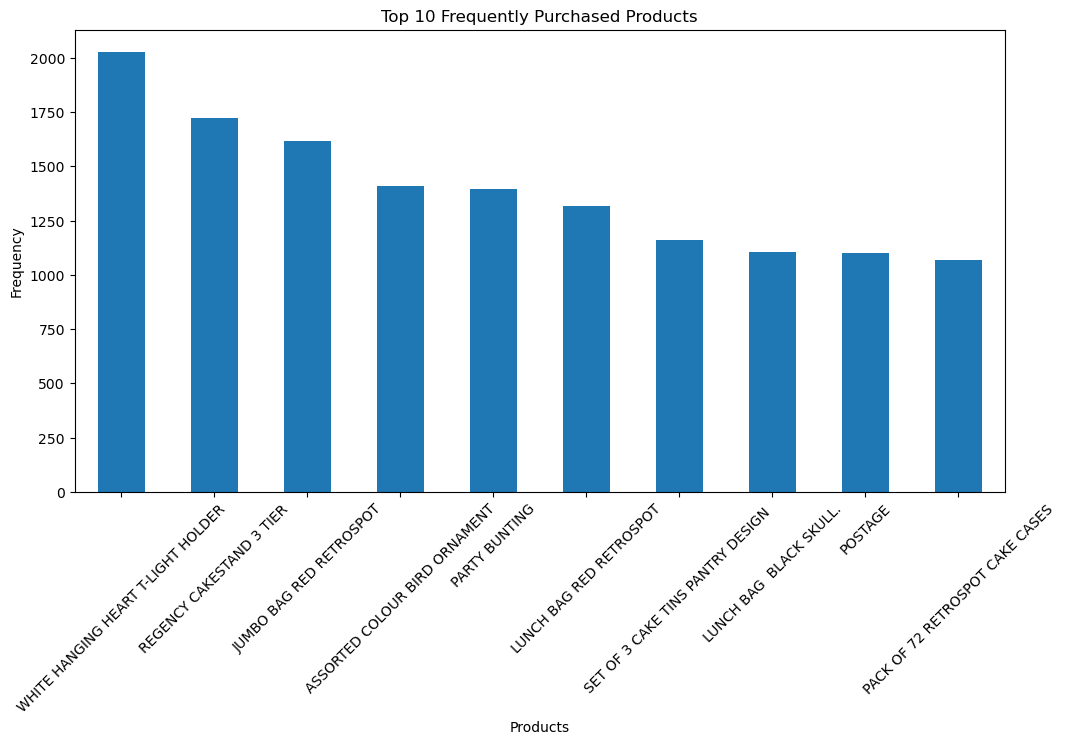

In [23]:
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Frequently Purchased Products")

plt.xlabel("Products")

plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()




SAVE OUTPUT
Save association rules into a CSV file.

In [24]:
rules.to_csv(
    r"C:\Users\rjesh\association_rules_output.csv",
    index=False
)

print("Association Rules Saved Successfully")




Association Rules Saved Successfully


CONCLUSION

In this experiment, we successfully performed:

Data preprocessing

Transaction matrix creation

Binary encoding

Frequent itemset mining

Association rule generation

Visualization of product sales

Market Basket Analysis helps organizations:

Improve product recommendations

Increase sales

Optimize store layouts

Understand customer purchasing behavior

REAL-WORLD APPLICATIONS

Amazon Product Recommendation

Grocery Store Analysis

E-commerce Recommendation Systems

Pharmacy Product Analysis

Restaurant Combo Suggestions

Online Shopping Platforms

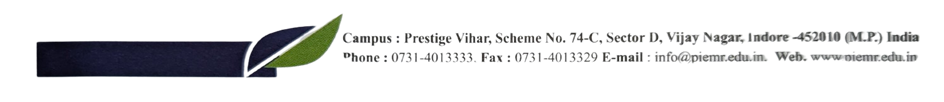